# Treinamento APTOS 2019 TCC 3 CoatNet — K-Fold, otimização bayesiana e soft voting



### Célula 1 — Instalar dependências


In [1]:
%pip install -q python-dotenv

Note: you may need to restart the kernel to use updated packages.


### Célula 2 — Configurar autenticação para pesos pré-treinados

O token é usado apenas para autenticação/download, métricas ou velocidade do treinamento depois que os pesos foram carregados.

In [2]:
import os
from pathlib import Path

from huggingface_hub import whoami

from dotenv import load_dotenv

env_path = Path.cwd() / ".env"
load_dotenv(env_path, override=True)

if not os.getenv("HF_TOKEN"):
    raise RuntimeError(
        "HF_TOKEN não encontrado. Crie o arquivo .env na pasta do projeto."
    )

print("HF_TOKEN carregado com segurança.")

usuario = whoami()
print("Autenticado como:", usuario["name"])

/home/luis/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


HF_TOKEN carregado com segurança.
Autenticado como: wands77


### Célula 3 — Importar bibliotecas e registrar versões


In [3]:
%pip install -q kagglehub opencv-python-headless albumentations timm grad-cam optuna scikit-learn seaborn 

import gc
import json
import os
import platform
import random
from datetime import datetime, timezone
from importlib.metadata import PackageNotFoundError, version
from pathlib import Path

import albumentations as A
import cv2
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from albumentations.pytorch import ToTensorV2
from IPython.display import display
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    auc,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.utils import resample
from torch.utils.data import DataLoader, Dataset


def package_version(package_name):
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "não encontrada"


runtime_versions = {
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_runtime": torch.version.cuda,
    "GPU": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "timm": package_version("timm"),
    "albumentations": package_version("albumentations"),
    "scikit-learn": package_version("scikit-learn"),
    "optuna": package_version("optuna"),
    "kagglehub": package_version("kagglehub"),
}
display(pd.Series(runtime_versions, name="versão").to_frame())

Note: you may need to restart the kernel to use updated packages.


,versão
python,3.12.3
torch,2.13.0+cu130
cuda_runtime,13.0
GPU,NVIDIA GeForce RTX 3060 Ti
timm,1.0.29
albumentations,2.0.8
scikit-learn,1.9.0
optuna,4.9.0
kagglehub,1.0.2


### Célula 4 — Configurar o experimento e a reprodutibilidade

Define arquitetura, sementes, batch físico, acumulação, K-Fold, early stopping e limites da busca bayesiana. `TUNING_MAX_PER_CLASS` reduz somente a base usada pelo Optuna para manter o custo viável na T4; use `None` para otimizar com toda a base de desenvolvimento.

In [4]:
SEED = 42
MODEL_NAME = "coatnet_rmlp_2_rw_384"
IMAGE_SIZE = 384
NUM_CLASSES = 5
CLASS_NAMES = ["0: Sem RD", "1: Leve", "2: Moderada", "3: Severa", "4: Proliferativa"]

BATCH_SIZE = 4
ACCUMULATION_STEPS = 8
EFFECTIVE_BATCH_SIZE = BATCH_SIZE * ACCUMULATION_STEPS
NUM_WORKERS = 2

FINAL_N_SPLITS = 5
FINAL_MAX_EPOCHS = 1000
FINAL_PATIENCE = 20

N_TRIALS = 12
TUNING_EPOCHS = 8
TUNING_PATIENCE = 3
TUNING_MAX_PER_CLASS = 350
TUNING_VALID_SIZE = 0.20

PREPROCESS_GAMMA = 1.2
ARTIFACT_DIR = Path("artefatos_aptos_bayes")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def fixar_sementes(seed=SEED):
    """Configura as principais fontes de aleatoriedade usadas no experimento."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)


def seed_worker(worker_id):
    """Inicializa cada worker do DataLoader com uma semente reproduzível."""
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)


def criar_gerador(seed):
    generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


fixar_sementes(SEED)
print(f"Dispositivo: {device}")
print(f"Batch físico: {BATCH_SIZE}")
print(f"Passos de acumulação: {ACCUMULATION_STEPS}")
print(f"Batch efetivo: {EFFECTIVE_BATCH_SIZE}")

Dispositivo: cuda
Batch físico: 4
Passos de acumulação: 8
Batch efetivo: 32


### Célula 5 — Baixar e carregar os três splits rotulados

Carrega `train_1.csv`, `valid.csv` e `test.csv` da cópia organizada do APTOS. A base de desenvolvimento combina treino e validação; o teste permanece separado e não participa de tuning, oversampling ou K-Fold.

In [5]:
dataset_path = Path(kagglehub.dataset_download("mariaherrerot/aptos2019"))

split_files = {
    "train": {"csv": "train_1.csv", "images": "train_images/train_images"},
    "valid": {"csv": "valid.csv", "images": "val_images/val_images"},
    "test": {"csv": "test.csv", "images": "test_images/test_images"},
}

dataframes = {}
for split_name, split_info in split_files.items():
    csv_path = dataset_path / split_info["csv"]
    image_dir = dataset_path / split_info["images"]

    if not csv_path.exists():
        raise FileNotFoundError(f"CSV não encontrado: {csv_path}")
    if not image_dir.exists():
        raise FileNotFoundError(f"Pasta de imagens não encontrada: {image_dir}")

    split_df = pd.read_csv(csv_path)
    required_columns = {"id_code", "diagnosis"}
    missing_columns = required_columns.difference(split_df.columns)
    if missing_columns:
        raise ValueError(f"{split_name}: colunas ausentes: {sorted(missing_columns)}")

    split_df = split_df.dropna(subset=["id_code", "diagnosis"]).copy()
    split_df["diagnosis"] = split_df["diagnosis"].astype(int)
    split_df["img_path"] = split_df["id_code"].map(
        lambda image_id, directory=image_dir: str(directory / f"{image_id}.png")
    )
    split_df["set_type"] = split_name
    dataframes[split_name] = split_df.reset_index(drop=True)

df_dev = pd.concat([dataframes["train"], dataframes["valid"]], ignore_index=True)
df_test = dataframes["test"].copy().reset_index(drop=True)

dev_ids = set(df_dev["id_code"])
test_ids = set(df_test["id_code"])
if dev_ids.intersection(test_ids):
    raise ValueError("Foram encontrados IDs em comum entre desenvolvimento e teste.")

print(f"Base de desenvolvimento: {len(df_dev)} imagens")
print(f"Hold-out final rotulado: {len(df_test)} imagens")
print(f"Caminho do dataset: {dataset_path}")

Base de desenvolvimento: 3296 imagens
Hold-out final rotulado: 366 imagens
Caminho do dataset: /home/luis/.cache/kagglehub/datasets/mariaherrerot/aptos2019/versions/3


### Célula 6 — Auditar integridade e distribuição dos dados

Verifica IDs duplicados, rótulos inválidos, arquivos ausentes e distribuição das classes antes de qualquer treinamento.

,linhas,ids_duplicados,rotulos_invalidos,imagens_ausentes
split,,,,
train,2930,0,0,0
valid,366,0,0,0
test,366,0,0,0
dev,3296,0,0,0


,desenvolvimento,teste
0: Sem RD,1606,199
1: Leve,340,30
2: Moderada,912,87
3: Severa,176,17
4: Proliferativa,262,33


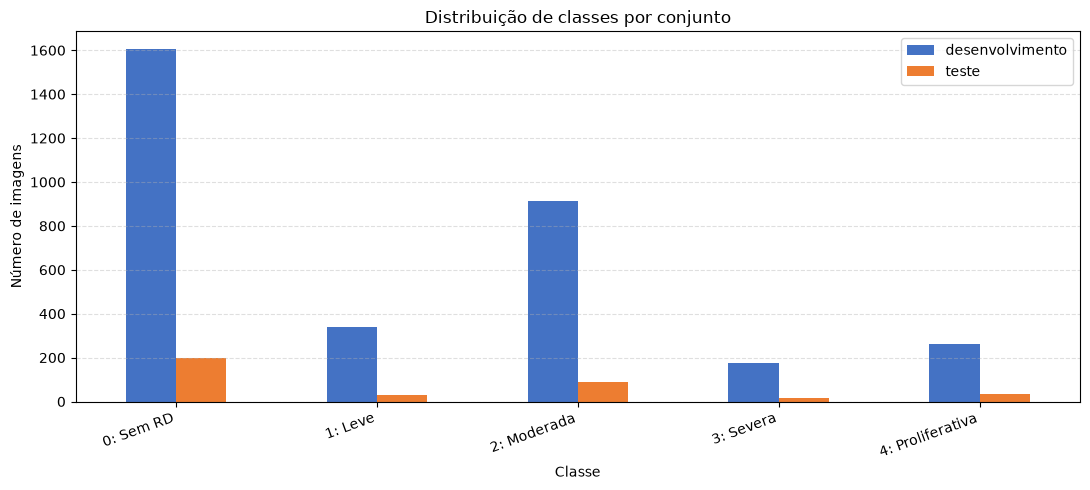

In [6]:
quality_rows = []
for split_name, split_df in {**dataframes, "dev": df_dev}.items():
    missing_images = int((~split_df["img_path"].map(os.path.exists)).sum())
    quality_rows.append(
        {
            "split": split_name,
            "linhas": len(split_df),
            "ids_duplicados": int(split_df["id_code"].duplicated().sum()),
            "rotulos_invalidos": int((~split_df["diagnosis"].isin(range(NUM_CLASSES))).sum()),
            "imagens_ausentes": missing_images,
        }
    )

quality_df = pd.DataFrame(quality_rows).set_index("split")
display(quality_df)

if quality_df[["ids_duplicados", "rotulos_invalidos", "imagens_ausentes"]].to_numpy().sum() != 0:
    raise ValueError("A auditoria encontrou problemas que devem ser corrigidos antes do treinamento.")

distribution_df = pd.concat(
    {
        "desenvolvimento": df_dev["diagnosis"].value_counts().sort_index(),
        "teste": df_test["diagnosis"].value_counts().sort_index(),
    },
    axis=1,
).fillna(0).astype(int)
distribution_df.index = CLASS_NAMES
display(distribution_df)

distribution_df.plot(kind="bar", figsize=(11, 5), color=["#4472C4", "#ED7D31"])
plt.title("Distribuição de classes por conjunto")
plt.xlabel("Classe")
plt.ylabel("Número de imagens")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

### Célula 7 — Definir o pré-processamento determinístico

Aplica corte das bordas, redimensionamento, correção gamma, filtro de Ben Graham e CLAHE. Na implementação usada, `gamma > 1` clareia os níveis intermediários.

In [7]:
def crop_image_from_gray(image, tolerance=7):
    """Remove bordas escuras preservando a imagem quando não existe área válida."""
    if image.ndim == 2:
        mask = image > tolerance
        if not mask.any():
            return image
        return image[np.ix_(mask.any(1), mask.any(0))]

    if image.ndim == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        mask = gray_image > tolerance
        if not mask.any():
            return image
        channels = [channel[np.ix_(mask.any(1), mask.any(0))] for channel in cv2.split(image)]
        return np.stack(channels, axis=-1)

    return image


def adjust_gamma(image, gamma=1.0):
    """Aplica LUT gamma; nesta fórmula gamma > 1 clareia e gamma < 1 escurece."""
    safe_gamma = gamma if gamma > 0 else 0.1
    inverse_gamma = 1.0 / safe_gamma
    table = np.array(
        [((value / 255.0) ** inverse_gamma) * 255 for value in np.arange(256)],
        dtype="uint8",
    )
    return cv2.LUT(image, table)


def pre_processar_base(image_rgb, sigma_x=10, image_size=IMAGE_SIZE, gamma=PREPROCESS_GAMMA):
    """Executa o pré-processamento base comum a treino, validação e teste."""
    image = crop_image_from_gray(image_rgb)
    image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_AREA)
    image = adjust_gamma(image, gamma=gamma)
    image_bg = cv2.addWeighted(image, 4, cv2.GaussianBlur(image, (0, 0), sigma_x), -4, 128)
    red, green, blue = cv2.split(image_bg)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    green_clahe = clahe.apply(green)
    return cv2.merge((red, green_clahe, blue))

### Célula 8 — Definir aumentos, normalização e Dataset

O treino recebe aumentos aleatórios; validação e teste recebem somente normalização. O Dataset exige uma transformação explícita para evitar variáveis indefinidas.

In [8]:
train_transforms = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.Rotate(limit=20, p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
        A.GaussNoise(std_range=(0.01, 0.03), p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)

eval_transforms = A.Compose(
    [
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ]
)


class RetinopatiaDataset(Dataset):
    """Dataset de imagens APTOS com pré-processamento comum e transformação configurável."""

    def __init__(self, dataframe, transform):
        if transform is None:
            raise ValueError("Uma transformação deve ser fornecida ao Dataset.")
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image = cv2.imread(row["img_path"])
        if image is None:
            raise FileNotFoundError(f"Não foi possível carregar: {row['img_path']}")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = pre_processar_base(image)
        image_tensor = self.transform(image=image)["image"]
        label = torch.tensor(int(row["diagnosis"]), dtype=torch.long)
        return image_tensor, label

### Célula 9 — Inspecionar o pré-processamento sem aumentos aleatórios

Compara imagens brutas com o pré-processamento determinístico. A célula não usa os aumentos de treino, evitando atribuir flips ou ruído ao filtro de Ben Graham.

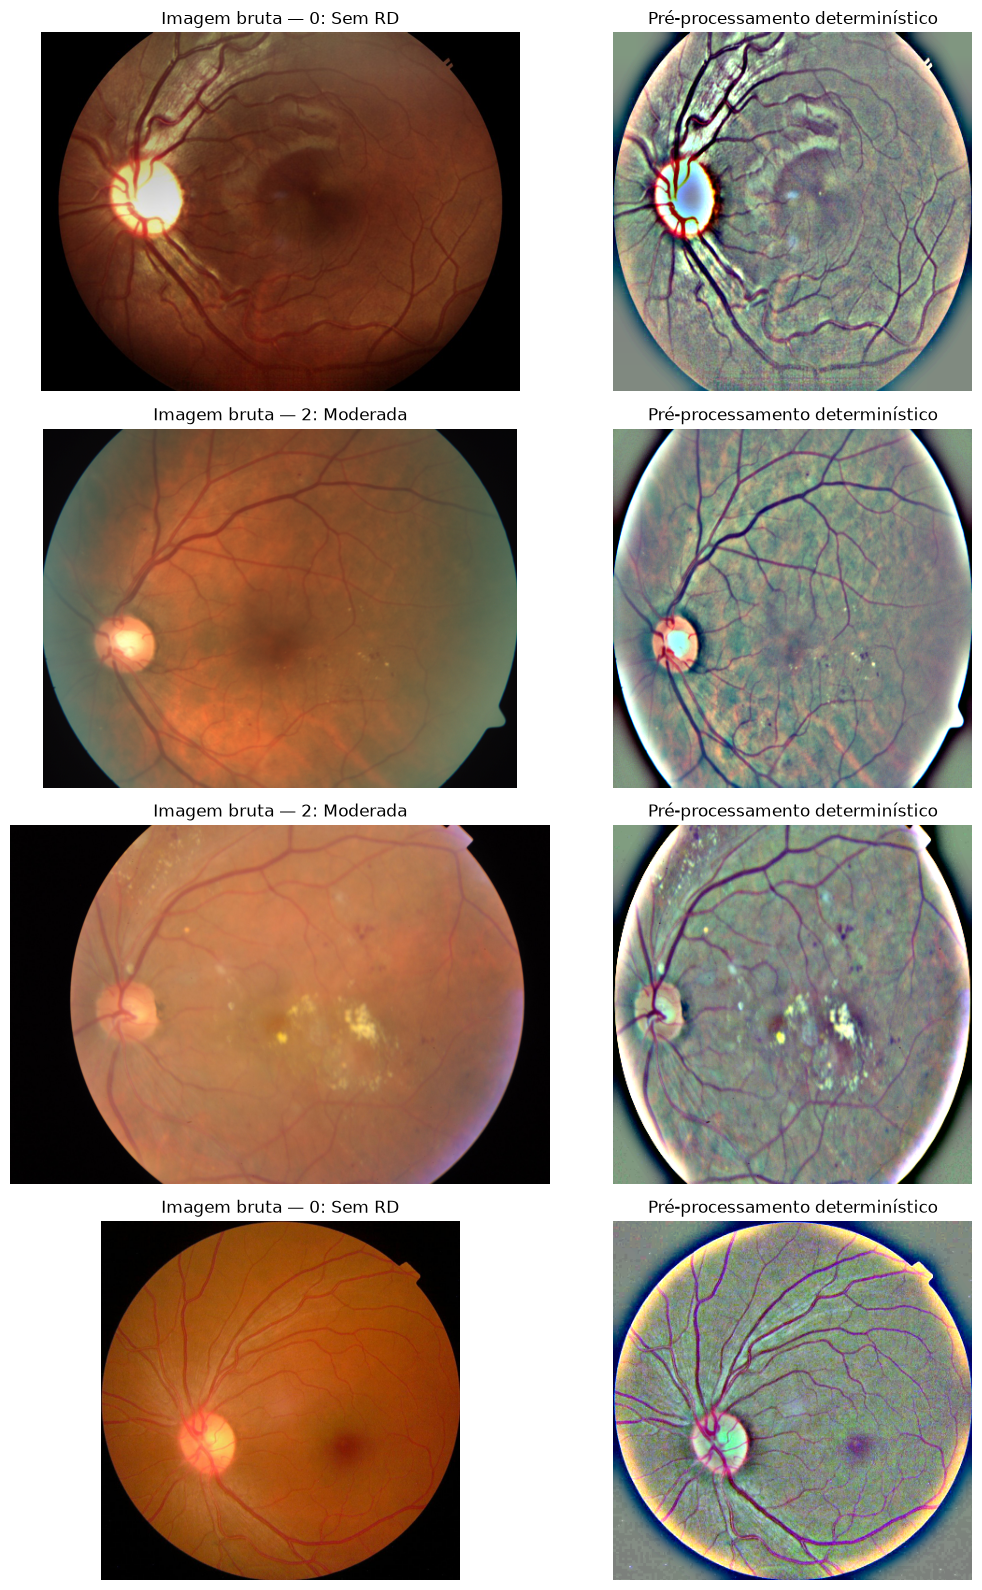

In [9]:
sample_rows = df_dev.sample(n=min(4, len(df_dev)), random_state=SEED)
fig, axes = plt.subplots(len(sample_rows), 2, figsize=(11, 4 * len(sample_rows)))
axes = np.atleast_2d(axes)

for axis_row, (_, row) in zip(axes, sample_rows.iterrows()):
    raw_bgr = cv2.imread(row["img_path"])
    raw_rgb = cv2.cvtColor(raw_bgr, cv2.COLOR_BGR2RGB)
    processed_rgb = pre_processar_base(raw_rgb)

    axis_row[0].imshow(raw_rgb)
    axis_row[0].set_title(f"Imagem bruta — {CLASS_NAMES[int(row['diagnosis'])]}")
    axis_row[0].axis("off")

    axis_row[1].imshow(processed_rgb)
    axis_row[1].set_title("Pré-processamento determinístico")
    axis_row[1].axis("off")

plt.tight_layout()
plt.show()

### Célula 10 — Corrigir o oversampling

Mantém todas as amostras originais de cada classe e sorteia apenas a quantidade adicional necessária. Assim, nenhuma imagem original é excluída pela reamostragem com reposição.

In [10]:
def balancear_com_oversampling(dataframe, seed=SEED):
    """Balanceia classes incluindo todos os originais e adicionando somente cópias extras."""
    target_size = int(dataframe["diagnosis"].value_counts().max())
    balanced_parts = []

    for class_label in sorted(dataframe["diagnosis"].unique()):
        class_df = dataframe[dataframe["diagnosis"] == class_label].copy()
        balanced_parts.append(class_df)

        extra_count = target_size - len(class_df)
        if extra_count > 0:
            extra_rows = resample(
                class_df,
                replace=True,
                n_samples=extra_count,
                random_state=seed + int(class_label),
            )
            balanced_parts.append(extra_rows)

    balanced_df = pd.concat(balanced_parts, ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=seed).reset_index(drop=True)

    original_ids = set(dataframe["id_code"])
    balanced_ids = set(balanced_df["id_code"])
    if not original_ids.issubset(balanced_ids):
        raise AssertionError("O oversampling excluiu uma ou mais imagens originais.")

    return balanced_df


oversampling_check = balancear_com_oversampling(df_dev, seed=SEED)
display(
    pd.concat(
        {
            "antes": df_dev["diagnosis"].value_counts().sort_index(),
            "depois": oversampling_check["diagnosis"].value_counts().sort_index(),
        },
        axis=1,
    )
)
del oversampling_check

,antes,depois
diagnosis,,
0,1606,1606
1,340,1606
2,912,1606
3,176,1606
4,262,1606


### Célula 11 — Definir métricas e avaliação

Calcula QWK, métricas macro e ponderadas, acurácia balanceada, AUC e recall de cada classe. Também define uma função separada de inferência que gera as probabilidades dos modelos no teste sem calcular métricas durante o treinamento dos folds.

In [11]:
def calcular_metricas(labels, probabilities):
    """Calcula métricas multiclasse a partir dos rótulos e probabilidades."""
    labels = np.asarray(labels, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    predictions = probabilities.argmax(axis=1)

    metrics = {
        "accuracy": accuracy_score(labels, predictions),
        "balanced_accuracy": balanced_accuracy_score(labels, predictions),
        "kappa": cohen_kappa_score(labels, predictions, weights="quadratic"),
        "f1_macro": f1_score(labels, predictions, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, predictions, average="weighted", zero_division=0),
        "precision_macro": precision_score(labels, predictions, average="macro", zero_division=0),
        "recall_macro": recall_score(labels, predictions, average="macro", zero_division=0),
    }

    try:
        metrics["auc_ovr_macro"] = roc_auc_score(
            labels, probabilities, multi_class="ovr", average="macro"
        )
        metrics["auc_ovr_weighted"] = roc_auc_score(
            labels, probabilities, multi_class="ovr", average="weighted"
        )
    except ValueError:
        metrics["auc_ovr_macro"] = np.nan
        metrics["auc_ovr_weighted"] = np.nan

    for class_index in range(NUM_CLASSES):
        class_mask = labels == class_index
        metrics[f"recall_class_{class_index}"] = (
            float(np.mean(predictions[class_mask] == class_index)) if class_mask.any() else np.nan
        )

    return metrics


def evaluate_model(model, dataloader, criterion, device):
    """Executa inferência e devolve loss, métricas, probabilidades e rótulos."""
    model.eval()
    running_loss = 0.0
    all_probabilities = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            logits = model(images)
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)
            all_probabilities.append(F.softmax(logits, dim=1).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    probabilities = np.vstack(all_probabilities)
    labels = np.concatenate(all_labels)
    metrics = calcular_metricas(labels, probabilities)
    metrics["loss"] = running_loss / len(dataloader.dataset)
    return metrics, probabilities, labels


def predict_probabilities(model, dataloader, device):
    """Gera probabilidades sem consultar rótulos nem calcular métricas."""
    model.eval()
    all_probabilities = []

    with torch.no_grad():
        for images, _ in dataloader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            all_probabilities.append(F.softmax(logits, dim=1).cpu().numpy())

    return np.vstack(all_probabilities)

### Célula 12 — Definir treino com AMP e acumulação correta

O batch físico 4 e acumula oito passos. O último grupo divide a loss pelo número real de lotes restantes, evitando reduzir artificialmente sua atualização.

In [12]:
def criar_grad_scaler(device):
    """Cria GradScaler compatível com versões recentes e anteriores do PyTorch."""
    enabled = device.type == "cuda"
    try:
        return torch.amp.GradScaler("cuda", enabled=enabled)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=enabled)


def train_one_epoch(model, dataloader, criterion, optimizer, device, accumulation_steps):
    """Treina uma época com mixed precision e acumulação de gradientes."""
    model.train()
    running_loss = 0.0
    all_predictions = []
    all_labels = []
    scaler = criar_grad_scaler(device)
    number_of_batches = len(dataloader)
    optimizer.zero_grad(set_to_none=True)

    for batch_index, (images, labels) in enumerate(dataloader):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        group_start = (batch_index // accumulation_steps) * accumulation_steps
        actual_group_size = min(accumulation_steps, number_of_batches - group_start)

        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            logits = model(images)
            raw_loss = criterion(logits, labels)
            scaled_loss = raw_loss / actual_group_size

        scaler.scale(scaled_loss).backward()

        is_group_end = (batch_index + 1) % accumulation_steps == 0
        is_last_batch = (batch_index + 1) == number_of_batches
        if is_group_end or is_last_batch:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += raw_loss.item() * images.size(0)
        all_predictions.extend(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    return {
        "loss": running_loss / len(dataloader.dataset),
        "accuracy": accuracy_score(all_labels, all_predictions),
        "kappa": cohen_kappa_score(all_labels, all_predictions, weights="quadratic"),
    }

### Célula 13 — Criar DataLoaders e modelos

Centraliza a construção dos loaders, do CoAtNet, da loss e do AdamW. Os hiperparâmetros retornados pelo Optuna serão reutilizados em todos os folds finais.

In [13]:
def criar_dataloader(dataframe, transform, batch_size, shuffle, seed):
    dataset = RetinopatiaDataset(dataframe, transform=transform)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=device.type == "cuda",
        worker_init_fn=seed_worker,
        generator=criar_gerador(seed),
        persistent_workers=NUM_WORKERS > 0,
    )


def criar_modelo(params, pretrained=True):
    """Cria o CoAtNet com dropout configurado pelo estudo bayesiano."""
    return timm.create_model(
        MODEL_NAME,
        pretrained=pretrained,
        num_classes=NUM_CLASSES,
        img_size=IMAGE_SIZE,
        drop_rate=float(params["drop_rate"]),
    )


def criar_componentes_treino(model, params):
    criterion = nn.CrossEntropyLoss(label_smoothing=float(params["label_smoothing"]))
    optimizer = optim.AdamW(
        model.parameters(),
        lr=float(params["learning_rate"]),
        weight_decay=float(params["weight_decay"]),
    )
    return criterion, optimizer

### Célula 14 — Preparar uma base fixa para otimização bayesiana

Cria uma amostra estratificada e um único split de tuning. O teste oficial reorganizado não participa desta etapa. O mesmo split é usado em todos os trials para tornar a comparação justa.

In [14]:
def criar_base_tuning(dataframe, max_per_class, seed=SEED):
    if max_per_class is None:
        return dataframe.sample(frac=1, random_state=seed).reset_index(drop=True)

    sampled_parts = []
    for class_label, class_df in dataframe.groupby("diagnosis"):
        sample_size = min(len(class_df), int(max_per_class))
        sampled_parts.append(class_df.sample(n=sample_size, random_state=seed + int(class_label)))
    return pd.concat(sampled_parts, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)


df_tuning = criar_base_tuning(df_dev, TUNING_MAX_PER_CLASS, seed=SEED)
df_tuning_train, df_tuning_valid = train_test_split(
    df_tuning,
    test_size=TUNING_VALID_SIZE,
    stratify=df_tuning["diagnosis"],
    random_state=SEED,
)
df_tuning_train = df_tuning_train.reset_index(drop=True)
df_tuning_valid = df_tuning_valid.reset_index(drop=True)

print(f"Tuning treino antes do oversampling: {len(df_tuning_train)}")
print(f"Tuning validação intacta: {len(df_tuning_valid)}")
display(
    pd.concat(
        {
            "treino_tuning": df_tuning_train["diagnosis"].value_counts().sort_index(),
            "valid_tuning": df_tuning_valid["diagnosis"].value_counts().sort_index(),
        },
        axis=1,
    )
)

Tuning treino antes do oversampling: 1182
Tuning validação intacta: 296


,treino_tuning,valid_tuning
diagnosis,,
0,280,70
1,272,68
2,280,70
3,141,35
4,209,53


### Célula 15 — Definir o objetivo bayesiano do Optuna

O sampler TPE escolhe learning rate, weight decay, dropout e label smoothing. Cada trial maximiza QWK na validação de tuning, usa early stopping e pode ser interrompido pelo pruner.

In [15]:
def objective(trial):
    trial_seed = SEED + 10_000 + trial.number
    fixar_sementes(trial_seed)

    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-4, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 5e-2, log=True),
        "drop_rate": trial.suggest_float("drop_rate", 0.0, 0.4, step=0.1),
        "label_smoothing": trial.suggest_float("label_smoothing", 0.0, 0.2, step=0.05),
    }

    balanced_train = balancear_com_oversampling(df_tuning_train, seed=trial_seed)
    train_loader = criar_dataloader(
        balanced_train, train_transforms, BATCH_SIZE, shuffle=True, seed=trial_seed
    )
    valid_loader = criar_dataloader(
        df_tuning_valid, eval_transforms, BATCH_SIZE, shuffle=False, seed=trial_seed + 1
    )

    model = criar_modelo(params, pretrained=True).to(device)
    criterion, optimizer = criar_componentes_treino(model, params)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=1
    )

    best_kappa = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0

    try:
        for epoch in range(TUNING_EPOCHS):
            train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                device,
                ACCUMULATION_STEPS,
            )
            valid_metrics, _, _ = evaluate_model(model, valid_loader, criterion, device)
            current_kappa = valid_metrics["kappa"]
            scheduler.step(current_kappa)

            trial.report(current_kappa, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned()

            if current_kappa > best_kappa:
                best_kappa = current_kappa
                best_epoch = epoch + 1
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            if epochs_without_improvement >= TUNING_PATIENCE:
                break
    finally:
        del model, criterion, optimizer, scheduler, train_loader, valid_loader
        torch.cuda.empty_cache()
        gc.collect()

    trial.set_user_attr("best_epoch", best_epoch)
    return float(best_kappa)

### Célula 16 — Executar a otimização bayesiana

Cria um estudo persistente em SQLite. Reexecutar a célula continua o estudo existente e adiciona novos trials. O processo é sequencial (`n_jobs=1`) porque todos os trials usam a mesma GPU.

In [ ]:
study_database = ARTIFACT_DIR / "optuna_aptos.db"
study = optuna.create_study(
    study_name="coatnet_aptos_tpe",
    direction="maximize",
    sampler=TPESampler(seed=SEED, n_startup_trials=4),
    pruner=MedianPruner(n_startup_trials=4, n_warmup_steps=1),
    storage=f"sqlite:///{study_database.resolve().as_posix()}",
    load_if_exists=True,
)

study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, gc_after_trial=True, show_progress_bar=True)

best_params = dict(study.best_trial.params)
print(f"Melhor QWK de tuning: {study.best_value:.4f}")
print("Melhores hiperparâmetros:")
print(json.dumps(best_params, indent=2, ensure_ascii=False))

trials_df = study.trials_dataframe()
display(
    trials_df.sort_values("value", ascending=False)
    .head(15)
    .reset_index(drop=True)
)
trials_df.to_csv(ARTIFACT_DIR / "optuna_trials.csv", index=False)

[I 2026-09-02 10:34:36,159] Using an existing study with name 'coatnet_aptos_tpe' instead of creating a new one.
  0%|          | 0/12 [00:00<?, ?it/s]/home/luis/.venv/lib/python3.12/site-packages/torch/autograd/graph.py:979: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at /__w/pytorch/pytorch/aten/src/ATen/native/transformers/cuda/attention_backward.cu:833.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


### Célula 17 — Definir o treinamento de um fold final

Treina um fold com os melhores hiperparâmetros, salva o checkpoint de maior QWK e recarrega esse checkpoint antes de gerar probabilidades OOF.

In [ ]:
def carregar_checkpoint(checkpoint_path, device):
    try:
        return torch.load(checkpoint_path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(checkpoint_path, map_location=device)


def treinar_fold(fold_number, fold_train_df, fold_valid_df, params):
    fold_seed = SEED + fold_number
    fixar_sementes(fold_seed)

    balanced_train = balancear_com_oversampling(fold_train_df, seed=fold_seed)
    train_loader = criar_dataloader(
        balanced_train, train_transforms, BATCH_SIZE, shuffle=True, seed=fold_seed
    )
    valid_loader = criar_dataloader(
        fold_valid_df, eval_transforms, BATCH_SIZE, shuffle=False, seed=fold_seed + 100
    )

    model = criar_modelo(params, pretrained=True).to(device)
    criterion, optimizer = criar_componentes_treino(model, params)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=5
    )

    checkpoint_path = ARTIFACT_DIR / f"best_model_fold_{fold_number}.pth"
    history = []
    best_kappa = -np.inf
    best_epoch = 0
    epochs_without_improvement = 0

    for epoch in range(1, FINAL_MAX_EPOCHS + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            ACCUMULATION_STEPS,
        )
        valid_metrics, _, _ = evaluate_model(model, valid_loader, criterion, device)
        scheduler.step(valid_metrics["kappa"])

        epoch_record = {
            "fold": fold_number,
            "epoch": epoch,
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"valid_{key}": value for key, value in valid_metrics.items()},
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(epoch_record)

        print(
            f"Fold {fold_number} | época {epoch:03d} | "
            f"train loss={train_metrics['loss']:.4f} kappa={train_metrics['kappa']:.4f} | "
            f"valid loss={valid_metrics['loss']:.4f} kappa={valid_metrics['kappa']:.4f} "
            f"f1_macro={valid_metrics['f1_macro']:.4f}"
        )

        if valid_metrics["kappa"] > best_kappa:
            best_kappa = valid_metrics["kappa"]
            best_epoch = epoch
            epochs_without_improvement = 0
            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "fold": fold_number,
                    "epoch": epoch,
                    "best_valid_metrics": valid_metrics,
                    "params": params,
                    "model_name": MODEL_NAME,
                    "image_size": IMAGE_SIZE,
                    "class_names": CLASS_NAMES,
                },
                checkpoint_path,
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= FINAL_PATIENCE:
            print(f"Early stopping no fold {fold_number}, época {epoch}.")
            break

    checkpoint = carregar_checkpoint(checkpoint_path, device)
    model.load_state_dict(checkpoint["model_state_dict"])
    final_valid_metrics, valid_probabilities, valid_labels = evaluate_model(
        model, valid_loader, criterion, device
    )

    return {
        "model": model,
        "criterion": criterion,
        "valid_metrics": final_valid_metrics,
        "valid_probabilities": valid_probabilities,
        "valid_labels": valid_labels,
        "best_epoch": best_epoch,
        "history": pd.DataFrame(history),
        "checkpoint_path": checkpoint_path,
    }

### Célula 18 — Executar o K-Fold final e gerar probabilidades OOF

Treina cinco modelos na base de desenvolvimento. Cada amostra recebe previsão somente do modelo que não a utilizou no treino. Para o teste, são armazenadas as probabilidades independentes dos cinco folds; elas serão combinadas por soft voting somente após o término de todo o treinamento.

In [ ]:
final_splitter = StratifiedKFold(n_splits=FINAL_N_SPLITS, shuffle=True, random_state=SEED)
oof_probabilities = np.full((len(df_dev), NUM_CLASSES), np.nan, dtype=np.float32)
fold_test_probabilities = []
fold_metrics_rows = []
fold_histories = []

test_dataset = RetinopatiaDataset(df_test, transform=eval_transforms)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
    worker_init_fn=seed_worker,
    generator=criar_gerador(SEED + 999),
    persistent_workers=NUM_WORKERS > 0,
)

for fold_number, (train_indices, valid_indices) in enumerate(
    final_splitter.split(df_dev, df_dev["diagnosis"]), start=1
):
    print("\n" + "=" * 70)
    print(f"INICIANDO FOLD {fold_number}/{FINAL_N_SPLITS}")
    print("=" * 70)

    fold_train_df = df_dev.iloc[train_indices].reset_index(drop=True)
    fold_valid_df = df_dev.iloc[valid_indices].reset_index(drop=True)
    fold_result = treinar_fold(
        fold_number,
        fold_train_df,
        fold_valid_df,
        best_params,
    )

    expected_valid_labels = df_dev.iloc[valid_indices]["diagnosis"].to_numpy()
    if not np.array_equal(fold_result["valid_labels"], expected_valid_labels):
        raise AssertionError(f"A ordem dos rótulos OOF divergiu no fold {fold_number}.")

    oof_probabilities[valid_indices] = fold_result["valid_probabilities"]
    fold_metrics_rows.append(
        {
            "fold": fold_number,
            "best_epoch": fold_result["best_epoch"],
            **fold_result["valid_metrics"],
        }
    )
    fold_histories.append(fold_result["history"])

    test_probs = predict_probabilities(fold_result["model"], test_loader, device)
    fold_test_probabilities.append(test_probs)

    del fold_result
    torch.cuda.empty_cache()
    gc.collect()

if np.isnan(oof_probabilities).any():
    raise AssertionError("Existem posições OOF sem probabilidades.")

fold_test_probabilities = np.stack(fold_test_probabilities, axis=0)
fold_metrics_df = pd.DataFrame(fold_metrics_rows)
training_history_df = pd.concat(fold_histories, ignore_index=True)

np.savez_compressed(
    ARTIFACT_DIR / "probabilidades_oof_e_teste.npz",
    oof_probabilities=oof_probabilities,
    oof_labels=df_dev["diagnosis"].to_numpy(),
    fold_test_probabilities=fold_test_probabilities,
    test_labels=df_test["diagnosis"].to_numpy(),
)
fold_metrics_df.to_csv(ARTIFACT_DIR / "metricas_validacao_por_fold.csv", index=False)
training_history_df.to_csv(ARTIFACT_DIR / "historico_treinamento.csv", index=False)

display(fold_metrics_df)

### Célula 19 — Calcular média e desvio-padrão

Resume as métricas de validação dos cinco folds usando desvio-padrão amostral (`ddof=1`). Também mede a variação dos cinco modelos individuais no mesmo teste; essa segunda variação não é um intervalo de confiança do conjunto de dados.

In [ ]:
metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "kappa",
    "f1_macro",
    "f1_weighted",
    "precision_macro",
    "recall_macro",
    "auc_ovr_macro",
    "auc_ovr_weighted",
    *[f"recall_class_{index}" for index in range(NUM_CLASSES)],
]

cv_summary = fold_metrics_df[metric_columns].agg(["mean", "std"]).T
cv_summary.columns = ["media_cv", "desvio_padrao_cv"]
display(cv_summary.style.format("{:.4f}"))
cv_summary.to_csv(ARTIFACT_DIR / "resumo_media_desvio_cv.csv")

test_labels = df_test["diagnosis"].to_numpy()
individual_test_metrics = []
for fold_index, probabilities in enumerate(fold_test_probabilities, start=1):
    individual_test_metrics.append(
        {"fold": fold_index, **calcular_metricas(test_labels, probabilities)}
    )

individual_test_metrics_df = pd.DataFrame(individual_test_metrics)
test_model_variability = individual_test_metrics_df[metric_columns].agg(["mean", "std"]).T
test_model_variability.columns = ["media_modelos_teste", "desvio_padrao_modelos_teste"]

print("Variação entre os cinco modelos no mesmo hold-out:")
display(test_model_variability.style.format("{:.4f}"))
individual_test_metrics_df.to_csv(ARTIFACT_DIR / "metricas_teste_modelos_individuais.csv", index=False)
test_model_variability.to_csv(ARTIFACT_DIR / "resumo_media_desvio_modelos_teste.csv")

### Célula 20 — Combinar os cinco modelos por soft voting

O soft voting não treina um meta-modelo. Cada CoAtNet gera, para cada imagem de teste, um vetor com cinco probabilidades; a média aritmética desses cinco vetores produz a distribuição final do ensemble. O resultado mantém o mesmo formato conceitual das OOF — um vetor de cinco probabilidades por imagem — embora as OOF sejam usadas para avaliar o desenvolvimento e a média dos folds seja usada para a inferência final no teste.

In [ ]:
oof_labels = df_dev["diagnosis"].to_numpy()
expected_test_shape = (FINAL_N_SPLITS, len(df_test), NUM_CLASSES)
if fold_test_probabilities.shape != expected_test_shape:
    raise AssertionError(
        f"Formato inesperado das probabilidades dos folds: "
        f"{fold_test_probabilities.shape}; esperado {expected_test_shape}."
    )

if oof_probabilities.shape != (len(df_dev), NUM_CLASSES):
    raise AssertionError(f"Formato inesperado das probabilidades OOF: {oof_probabilities.shape}.")

# Soft voting: média não ponderada das probabilidades dos cinco CoAtNets.
soft_voting_test_probabilities = fold_test_probabilities.mean(axis=0)
soft_voting_test_predictions = soft_voting_test_probabilities.argmax(axis=1)

if soft_voting_test_probabilities.shape[1] != oof_probabilities.shape[1]:
    raise AssertionError("OOF e soft voting não possuem o mesmo número de classes.")

if not np.allclose(soft_voting_test_probabilities.sum(axis=1), 1.0, atol=1e-5):
    raise AssertionError("As probabilidades do soft voting não somam 1 por imagem.")

oof_global_metrics = calcular_metricas(oof_labels, oof_probabilities)
soft_voting_test_metrics = calcular_metricas(test_labels, soft_voting_test_probabilities)

final_metrics_df = pd.DataFrame(
    [
        {
            "avaliacao": "Desenvolvimento — OOF",
            "combinacao": "uma previsão fora do treino por imagem",
            **oof_global_metrics,
        },
        {
            "avaliacao": "Teste hold-out — soft voting",
            "combinacao": "média das probabilidades dos cinco folds",
            **soft_voting_test_metrics,
        },
    ]
).set_index("avaliacao")

display(final_metrics_df[["combinacao", *metric_columns]].style.format(
    {column: "{:.4f}" for column in metric_columns}
))
final_metrics_df.to_csv(ARTIFACT_DIR / "metricas_oof_e_soft_voting.csv")
np.savez_compressed(
    ARTIFACT_DIR / "resultado_soft_voting_teste.npz",
    probabilities=soft_voting_test_probabilities,
    predictions=soft_voting_test_predictions,
    labels=test_labels,
)

### Célula 21 — Exibir relatório e matriz de confusão final

Avalia o ensemble por soft voting no hold-out rotulado. O relatório e a matriz de confusão detalham o comportamento final em cada classe.

In [ ]:
print("RELATÓRIO FINAL — SOFT VOTING DOS CINCO FOLDS")
print(
    classification_report(
        test_labels,
        soft_voting_test_predictions,
        labels=np.arange(NUM_CLASSES),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)

matrix = confusion_matrix(
    test_labels, soft_voting_test_predictions, labels=np.arange(NUM_CLASSES)
)
fig, axis = plt.subplots(figsize=(10, 8))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=False,
    ax=axis,
)
axis.set_title("Matriz de confusão — soft voting")
axis.set_xlabel("Predição")
axis.set_ylabel("Rótulo real")

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "matriz_confusao_soft_voting.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Célula 22 — Plotar curvas ROC do soft voting

Apresenta a AUC one-vs-rest de cada classe usando as probabilidades finais do soft voting no teste. Para interpretar classes raras, use esta figura junto do recall, F1 macro e matriz de confusão.

In [ ]:
test_labels_binary = label_binarize(test_labels, classes=np.arange(NUM_CLASSES))
colors = ["#2E7D32", "#1565C0", "#EF6C00", "#C62828", "#6A1B9A"]

plt.figure(figsize=(10, 8))
for class_index in range(NUM_CLASSES):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        test_labels_binary[:, class_index],
        soft_voting_test_probabilities[:, class_index],
    )
    class_auc = auc(false_positive_rate, true_positive_rate)
    plt.plot(
        false_positive_rate,
        true_positive_rate,
        color=colors[class_index],
        linewidth=2,
        label=f"{CLASS_NAMES[class_index]} (AUC={class_auc:.3f})",
    )

plt.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Aleatório")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curvas ROC multiclasse — soft voting")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "roc_soft_voting.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Célula 23 — Visualizar uma predição final

Seleciona uma imagem do teste, mostra o ID correto da imagem e apresenta as probabilidades finais geradas pelo soft voting dos cinco CoAtNets. As probabilidades são estimativas do ensemble, não probabilidades clínicas calibradas.

In [ ]:
def visualizar_predicao_final(index=None):
    if index is None:
        index = int(np.random.default_rng(SEED).integers(0, len(test_dataset)))

    image_tensor, true_label = test_dataset[index]
    image_id = test_dataset.dataframe.iloc[index]["id_code"]
    probabilities = soft_voting_test_probabilities[index]
    predicted_label = int(probabilities.argmax())

    image_display = image_tensor.numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_display = np.clip(image_display * std + mean, 0, 1)

    _, axes = plt.subplots(1, 2, figsize=(13, 5))
    axes[0].imshow(image_display)
    axes[0].set_title(
        f"ID da imagem: {image_id}\n"
        f"Rótulo: {CLASS_NAMES[int(true_label)]}\n"
        f"Predição: {CLASS_NAMES[predicted_label]}"
    )
    axes[0].axis("off")

    bars = axes[1].bar(CLASS_NAMES, probabilities, color=colors)
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Probabilidade estimada")
    axes[1].set_title("Saída do soft voting")
    axes[1].tick_params(axis="x", rotation=25)
    for bar, probability in zip(bars, probabilities):
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            probability + 0.015,
            f"{probability:.1%}",
            ha="center",
        )

    plt.tight_layout()
    plt.show()


visualizar_predicao_final()

### Célula 24 — Gerar Grad-CAM++ de um CoAtNet individual

Cada mapa Grad-CAM++ é calculado sobre um único modelo CoAtNet, identificado pelo número do fold. O mapa mostra quais regiões influenciaram a predição desse modelo base individual e não explica diretamente o ensemble final por soft voting.


In [ ]:
def mostrar_gradcam_modelo_base(index=None, fold_number=1):
    """Gera Grad-CAM++ para um CoAtNet individual"""
    if index is None:
        index = int(np.random.default_rng(SEED + 1).integers(0, len(test_dataset)))

    print(
        f"AVISO: este Grad-CAM++ explica somente o CoAtNet individual do fold {fold_number}; "
        "não explica diretamente o ensemble por soft voting."
    )

    checkpoint_path = ARTIFACT_DIR / f"best_model_fold_{fold_number}.pth"
    checkpoint = carregar_checkpoint(checkpoint_path, device)
    base_model = criar_modelo(checkpoint["params"], pretrained=False).to(device)
    base_model.load_state_dict(checkpoint["model_state_dict"])
    base_model.eval()

    image_tensor, true_label = test_dataset[index]
    image_id = test_dataset.dataframe.iloc[index]["id_code"]
    input_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        predicted_class = int(base_model(input_tensor).argmax(dim=1).item())

    target_layers = [base_model.stages[-1]]
    targets = [ClassifierOutputTarget(predicted_class)]
    with GradCAMPlusPlus(model=base_model, target_layers=target_layers) as cam:
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    image_display = image_tensor.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    image_display = np.clip(image_display * std + mean, 0, 1).astype(np.float32)
    overlay = show_cam_on_image(image_display, grayscale_cam, use_rgb=True)

    figure, axes = plt.subplots(1, 3, figsize=(18, 6))
    figure.suptitle(
        f"Grad-CAM++ do CoAtNet individual — fold {fold_number}\n",
        fontsize=14,
        fontweight="bold",
    )
    axes[0].imshow(image_display)
    axes[0].set_title(f"ID da imagem: {image_id}\nImagem processada")
    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title(f"Mapa do CoAtNet individual — fold {fold_number}")
    axes[2].imshow(overlay)
    axes[2].set_title(
        f"Rótulo: {CLASS_NAMES[int(true_label)]}\n"
        f"Predição do CoAtNet fold {fold_number}: {CLASS_NAMES[predicted_class]}"
    )
    for axis in axes:
        axis.axis("off")
    plt.tight_layout(rect=(0, 0, 1, 0.90))
    plt.show()

    del base_model
    torch.cuda.empty_cache()


mostrar_gradcam_modelo_base()

### Célula 25 — Salvar o manifesto do experimento

Registra configuração, melhores hiperparâmetros, versões e data de execução junto aos checkpoints e métricas.

In [ ]:
experiment_manifest = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "dataset": "mariaherrerot/aptos2019",
    "development_rows": len(df_dev),
    "test_rows": len(df_test),
    "model_name": MODEL_NAME,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "accumulation_steps": ACCUMULATION_STEPS,
    "effective_batch_size": EFFECTIVE_BATCH_SIZE,
    "final_n_splits": FINAL_N_SPLITS,
    "final_max_epochs": FINAL_MAX_EPOCHS,
    "final_patience": FINAL_PATIENCE,
    "ensemble_method": "soft_voting_probability_mean",
    "tuning_trials_requested_this_run": N_TRIALS,
    "tuning_epochs": TUNING_EPOCHS,
    "tuning_max_per_class": TUNING_MAX_PER_CLASS,
    "best_hyperparameters": best_params,
    "runtime_versions": runtime_versions,
}

with open(ARTIFACT_DIR / "manifesto_experimento.json", "w", encoding="utf-8") as manifest_file:
    json.dump(experiment_manifest, manifest_file, indent=2, ensure_ascii=False)

print(f"Artefatos salvos em: {ARTIFACT_DIR.resolve()}")
print(json.dumps(experiment_manifest, indent=2, ensure_ascii=False))